# Ejercicio de penetracion indoor en edificio real

## Objetivo
Adaptar un caso de cobertura indoor a un edificio docente real para decidir si la cobertura macro exterior es suficiente o si hace falta refuerzo indoor para voz, mensajeria y acceso a plataformas digitales.

## Escenario
- Edificio de varias plantas con fachada, tabiqueria interior y un semisotano tecnico.
- Estacion base exterior en entorno campus.
- Altura de antena exterior: 22 m.
- Portadora principal: LTE 1800 MHz.
- Portadora de respaldo: UMTS 2100 MHz.
- Extension opcional: comparar con 800 MHz y 2600 MHz.

## Tareas
1. Definir tres puntos de usuario: entrada, aula de segunda planta y semisotano.
2. Calcular la perdida total: propagacion exterior + penetracion interior.
3. Comprobar si el nivel recibido supera los umbrales de servicio.
4. Recomendar macro suficiente o refuerzo indoor.

## Hipotesis de calculo

Se usa un modelo simplificado de enlace descendente con una perdida exterior tipo 3GPP UMa NLOS conservadora y un margen de sombra adicional.

- EIRP sector macro: 58 dBm
- Margen exterior adicional: 8 dB
- Umbral de voz y mensajeria: -100 dBm
- Umbral de datos basicos y acceso a plataformas: -95 dBm

Perdidas interiores de referencia:
- Fachada: 12 a 18 dB
- Pared interior: 3 a 5 dB
- Forjado: 12 a 18 dB
- Puerta tecnica corta-fuegos: 6 dB

Puntos de usuario seleccionados:
- Entrada principal
- Aula de segunda planta
- Archivo en semisotano

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 1)

In [2]:
EIRP_DBM = 58
SHADOW_MARGIN_DB = 8
VOICE_THRESHOLD_DBM = -100
DATA_THRESHOLD_DBM = -95
BS_HEIGHT_M = 22

points = [
    {
        'punto': 'Entrada principal',
        'planta': 'Baja',
        'altura_usuario_m': 1.5,
        'distancia_horizontal_m': 180,
        'fachada_db': 14,
        'paredes_db': 0,
        'forjados_db': 0,
        'extra_db': 0,
    },
    {
        'punto': 'Aula 2a planta',
        'planta': 'Segunda',
        'altura_usuario_m': 8.5,
        'distancia_horizontal_m': 170,
        'fachada_db': 16,
        'paredes_db': 4,
        'forjados_db': 15,
        'extra_db': 0,
    },
    {
        'punto': 'Archivo semisotano',
        'planta': 'Semisotano',
        'altura_usuario_m': -2.5,
        'distancia_horizontal_m': 185,
        'fachada_db': 18,
        'paredes_db': 8,
        'forjados_db': 18,
        'extra_db': 6,
    },
]

bands_mhz = {
    'LTE 1800': 1800,
    'UMTS 2100': 2100,
    'LTE 800': 800,
    'LTE 2600': 2600,
}

In [3]:
def outdoor_path_loss_db(distance_horizontal_m, user_height_m, frequency_mhz, shadow_margin_db=SHADOW_MARGIN_DB):
    """Modelo conservador tipo UMa NLOS con termino de frecuencia en GHz."""
    distance_3d_m = math.sqrt(distance_horizontal_m ** 2 + (BS_HEIGHT_M - user_height_m) ** 2)
    frequency_ghz = frequency_mhz / 1000
    return (
        13.54
        + 39.08 * math.log10(distance_3d_m)
        + 20 * math.log10(frequency_ghz)
        - 0.6 * (user_height_m - 1.5)
        + shadow_margin_db
    )


def classify_service(received_power_dbm):
    if received_power_dbm >= DATA_THRESHOLD_DBM:
        return 'Cumple voz y datos basicos'
    if received_power_dbm >= VOICE_THRESHOLD_DBM:
        return 'Cumple voz, datos justos'
    return 'No cumple objetivo'


def recommendation(received_power_dbm, point_name):
    if received_power_dbm >= DATA_THRESHOLD_DBM:
        if 'Entrada' in point_name:
            return 'Macro suficiente'
        return 'Macro suficiente para el objetivo base'
    if received_power_dbm >= VOICE_THRESHOLD_DBM:
        return 'Revisar refuerzo ligero: repetidor o small cell segun capacidad'
    return 'Refuerzo indoor necesario: small cell o DAS; repetidor solo si la senal donante es estable'

In [4]:
rows = []
for band_name, frequency_mhz in bands_mhz.items():
    for point in points:
        outdoor_loss = outdoor_path_loss_db(
            point['distancia_horizontal_m'],
            point['altura_usuario_m'],
            frequency_mhz,
        )
        indoor_loss = point['fachada_db'] + point['paredes_db'] + point['forjados_db'] + point['extra_db']
        total_loss = outdoor_loss + indoor_loss
        received_power = EIRP_DBM - total_loss
        rows.append({
            'banda': band_name,
            'punto': point['punto'],
            'planta': point['planta'],
            'dist_h_m': point['distancia_horizontal_m'],
            'L_ext_db': round(outdoor_loss, 1),
            'L_fachada_db': point['fachada_db'],
            'L_paredes_db': point['paredes_db'],
            'L_forjados_db': point['forjados_db'],
            'L_extra_db': point['extra_db'],
            'L_total_db': round(total_loss, 1),
            'P_rx_dbm': round(received_power, 1),
            'estado': classify_service(received_power),
            'recomendacion': recommendation(received_power, point['punto']),
        })

results = pd.DataFrame(rows)
main_results = results[results['banda'].isin(['LTE 1800', 'UMTS 2100'])].copy()
main_results

,banda,punto,planta,dist_h_m,L_ext_db,L_fachada_db,L_paredes_db,L_forjados_db,L_extra_db,L_total_db,P_rx_dbm,estado,recomendacion
0,LTE 1800,Entrada principal,Baja,180,114.9,14,0,0,0,128.9,-70.9,Cumple voz y datos basicos,Macro suficiente
1,LTE 1800,Aula 2a planta,Segunda,170,109.7,16,4,15,0,144.7,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,LTE 1800,Archivo semisotano,Semisotano,185,117.8,18,8,18,6,167.8,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...
3,UMTS 2100,Entrada principal,Baja,180,116.2,14,0,0,0,130.2,-72.2,Cumple voz y datos basicos,Macro suficiente
4,UMTS 2100,Aula 2a planta,Segunda,170,111.0,16,4,15,0,146.0,-88.0,Cumple voz y datos basicos,Macro suficiente para el objetivo base
5,UMTS 2100,Archivo semisotano,Semisotano,185,119.1,18,8,18,6,169.1,-111.1,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


## Tabla de perdidas por tramo

La tabla siguiente resume el caso principal con LTE 1800. Es el entregable minimo para el alumno.

In [5]:
lte_1800 = results[results['banda'] == 'LTE 1800'][[
    'punto',
    'L_ext_db',
    'L_fachada_db',
    'L_paredes_db',
    'L_forjados_db',
    'L_extra_db',
    'L_total_db',
    'P_rx_dbm',
    'estado',
    'recomendacion',
]]
lte_1800

,punto,L_ext_db,L_fachada_db,L_paredes_db,L_forjados_db,L_extra_db,L_total_db,P_rx_dbm,estado,recomendacion
0,Entrada principal,114.9,14,0,0,0,128.9,-70.9,Cumple voz y datos basicos,Macro suficiente
1,Aula 2a planta,109.7,16,4,15,0,144.7,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,Archivo semisotano,117.8,18,8,18,6,167.8,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


In [6]:
summary = lte_1800[['punto', 'P_rx_dbm', 'estado', 'recomendacion']].copy()
summary

,punto,P_rx_dbm,estado,recomendacion
0,Entrada principal,-70.9,Cumple voz y datos basicos,Macro suficiente
1,Aula 2a planta,-86.7,Cumple voz y datos basicos,Macro suficiente para el objetivo base
2,Archivo semisotano,-109.8,No cumple objetivo,Refuerzo indoor necesario: small cell o DAS; r...


## Croquis simplificado del edificio

Este croquis no sustituye un plano real, pero sirve para documentar el ejercicio y situar los puntos de medida. En un caso real, el siguiente paso seria exportar el plano a QGIS y georreferenciar la planta.

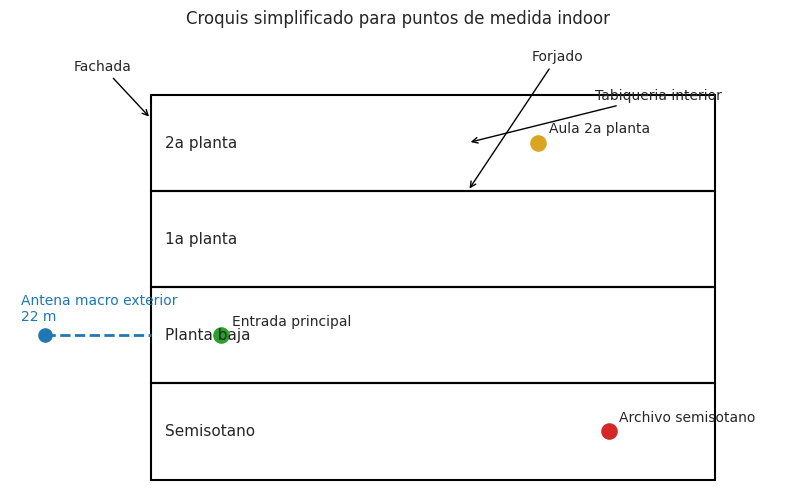

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

floors = [
    ('2a planta', 6, 8),
    ('1a planta', 4, 6),
    ('Planta baja', 2, 4),
    ('Semisotano', 0, 2),
]

for label, y0, y1 in floors:
    ax.add_patch(plt.Rectangle((2, y0), 8, y1 - y0, fill=False, linewidth=1.5, edgecolor='black'))
    ax.text(2.2, (y0 + y1) / 2, label, va='center', fontsize=11)

ax.plot([0.5, 2], [3, 3], linestyle='--', color='tab:blue', linewidth=2)
ax.scatter([0.5], [3], color='tab:blue', s=90)
ax.text(0.15, 3.3, 'Antena macro exterior\n22 m', color='tab:blue')

points_plot = {
    'Entrada principal': (3, 3),
    'Aula 2a planta': (7.5, 7),
    'Archivo semisotano': (8.5, 1),
}
colors = {
    'Entrada principal': 'tab:green',
    'Aula 2a planta': 'goldenrod',
    'Archivo semisotano': 'tab:red',
}

for name, (x_pos, y_pos) in points_plot.items():
    ax.scatter([x_pos], [y_pos], color=colors[name], s=120)
    ax.text(x_pos + 0.15, y_pos + 0.2, name, fontsize=10)

ax.annotate('Fachada', xy=(2, 7.5), xytext=(0.9, 8.5), arrowprops={'arrowstyle': '->'})
ax.annotate('Forjado', xy=(6.5, 6), xytext=(7.4, 8.7), arrowprops={'arrowstyle': '->'})
ax.annotate('Tabiqueria interior', xy=(6.5, 7), xytext=(8.3, 7.9), arrowprops={'arrowstyle': '->'})

ax.set_xlim(0, 11)
ax.set_ylim(-0.3, 9.3)
ax.set_title('Croquis simplificado para puntos de medida indoor')
ax.axis('off')
plt.show()

## Extension opcional por banda

La comparativa ayuda a reforzar la idea de que frecuencias mas bajas penetran mejor y frecuencias mas altas penalizan la cobertura indoor.

In [8]:
comparison = results.pivot(index='punto', columns='banda', values='P_rx_dbm').round(1)
comparison

banda,LTE 1800,LTE 2600,LTE 800,UMTS 2100
punto,,,,
Archivo semisotano,-109.8,-113.0,-102.8,-111.1
Aula 2a planta,-86.7,-89.9,-79.6,-88.0
Entrada principal,-70.9,-74.1,-63.8,-72.2


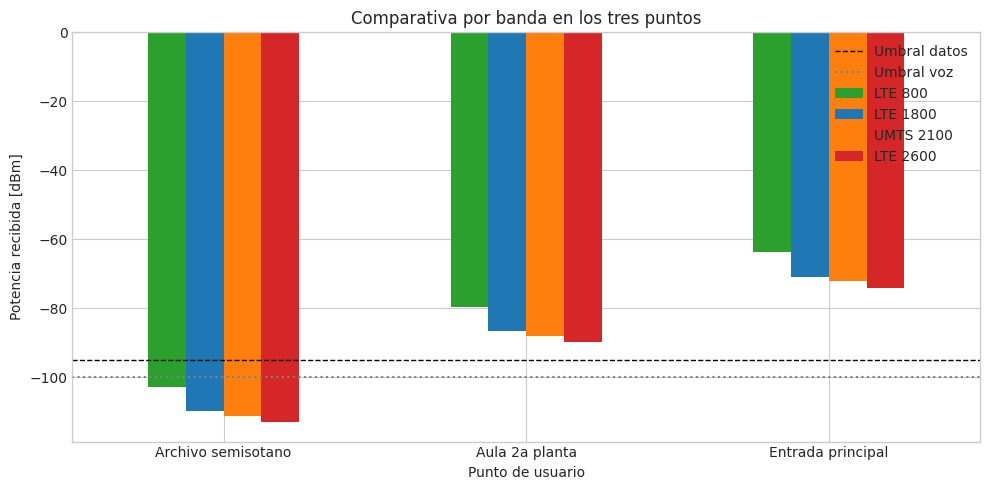

In [9]:
ax = comparison[['LTE 800', 'LTE 1800', 'UMTS 2100', 'LTE 2600']].plot(
    kind='bar',
    figsize=(10, 5),
    color=['tab:green', 'tab:blue', 'tab:orange', 'tab:red']
)
ax.axhline(DATA_THRESHOLD_DBM, color='black', linestyle='--', linewidth=1, label='Umbral datos')
ax.axhline(VOICE_THRESHOLD_DBM, color='gray', linestyle=':', linewidth=1.5, label='Umbral voz')
ax.set_ylabel('Potencia recibida [dBm]')
ax.set_xlabel('Punto de usuario')
ax.set_title('Comparativa por banda en los tres puntos')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
output_dir = Path('salidas')
output_dir.mkdir(exist_ok=True)
lte_1800.to_csv(output_dir / 'tabla_perdidas_lte1800.csv', index=False)
comparison.to_csv(output_dir / 'comparativa_bandas.csv')
summary.to_csv(output_dir / 'resumen_recomendaciones.csv', index=False)
print('Archivos exportados en', output_dir.resolve())

Archivos exportados en /workspaces/Cobertura-indoor-de-campus/salidas


## Conclusion esperada

Con los parametros elegidos, el ejercicio conduce a una conclusion razonable y facil de defender:

- La entrada principal queda cubierta por macro exterior.
- El aula de segunda planta cumple el objetivo base, pero con menos margen que la entrada.
- El semisotano no alcanza el objetivo y requiere refuerzo indoor.

Criterio de solucion de mejora:
- Small cell: preferible si se quiere servicio dedicado y buena capacidad para plataformas digitales.
- DAS: preferible si hay que repartir cobertura en varias plantas o dar servicio multioperador.
- Repetidor: solo cuando la senal donante exterior sea estable y la normativa lo permita.